# We will Work on MNIST data and it is is Multiclass-Classification problem so we will try to solve it using Backpropagation and see the whole flow of the data
- MNIST data set is an Image of 70k photos of low resolution in which numbers are written

# Architecture

- Input Layer:784 inputs,1 node for each pixel
- Hidden Layer:128 nodes
- Output Layer:10 nodes because it is a Multiclass Classification Problem and it this type of problem we include node counts in output layer equals to number of classes so it is a number hence we have 10 classes 0 to 9 and which ever class will have higher probability will be considered the output


In [29]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [30]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data() #mnist data

In [31]:
X_train.shape # this will include data of images in pixelated form it is a 3d Array
X_test #it is also a 3d array whose shape is 10000x28x28


array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [32]:
y_train # it has labels showing what type of data there is in the each segment of the X_train data
# hence we know 1st image has 5 in it 


array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

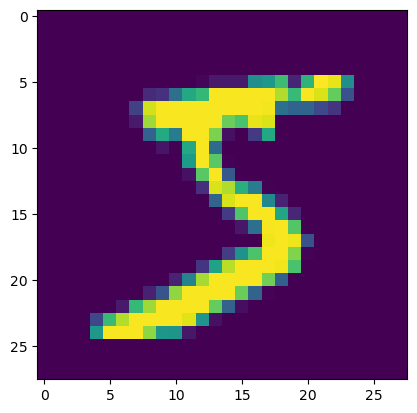

In [33]:
# Showing the pixelated data in image form using matplotlib
import matplotlib.pyplot as plt
plt.imshow(X_train[0])  # hence you can see it has letter 5

# Every image has values b/w 0 to 255 but we want to make it on same scale and less weight changings so we wish to make values b/w 0 to 1
- we will divide values by 255 to make it come in range

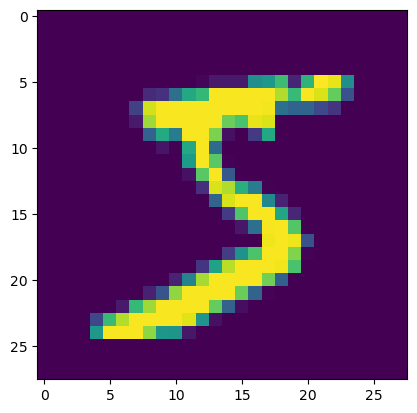

In [34]:
X_train=X_train/255
X_test=X_test/255

X_train[0] # Now values are b/w 0 to 1
plt.imshow(X_train[0])

In [35]:
model=Sequential() # this is our model which is Keras Sequential Model

# Issue is that we have data in format 28x28 but we want to give input of data like 784. so now we have to Flatten the Data.
model.add(Flatten(input_shape=(28,28))) # This will Flatten the data into 1D this will be out first Layer/Input Layer
model.add(Dense(128,activation='relu')) # Hidden layer
model.add(Dense(10,activation='softmax')) # When there are more than 1 node in the output use Softmax for it.

c:\Users\ashwi\anaconda3\envs\ashwiniAnaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam')

In [38]:
model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2863 - val_loss: 0.1653
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1281 - val_loss: 0.1203
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0877 - val_loss: 0.1151
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0646 - val_loss: 0.1011
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0495 - val_loss: 0.0929
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0393 - val_loss: 0.0874
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0312 - val_loss: 0.0853
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0236 - val_loss: 0.0976
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0197 - val_loss: 0.0942
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0167 - val_loss: 0.1024


In [39]:
y_prob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [41]:
y_pred=y_prob.argmax(axis=1)

In [42]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9747